In [1]:
# THE PLAN PART 1:
#    Send a ADQL query to the Gaia archive, 
#    asking it to return all the stars in a small patch of sky around NGC 2244,
#    Then, trimming down the data set for qualifying canadates
#    
#    NGC 2244    RA: 06h 32m 18s , DEC +04° 52′ 00″
#    
#    NGC 2244 itself spans about 30 arcminutes (0.5°), 
#        So we may want to search radius around 1 degree, 
#        giving us a generous field around the cluster 
#        this would give field-star background for contrast


In [2]:
pip install astroquery


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import astroquery
from astroquery.gaia import Gaia
import os

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [4]:
tables = Gaia.load_tables()

INFO: Retrieving tables... [astroquery.utils.tap.core]
INFO: Parsing tables... [astroquery.utils.tap.core]
INFO: Done. [astroquery.utils.tap.core]


In [5]:
#    These are the table names from our dataset
for i, tab in enumerate(tables):
    print (i, tab.name)

0 external.apassdr9
1 external.catwise2020
2 external.gaiadr2_astrophysical_parameters
3 external.gaiadr2_geometric_distance
4 external.gaiaedr3_distance
5 external.gaiaedr3_gcns_main_1
6 external.gaiaedr3_gcns_rejected_1
7 external.gaiaedr3_spurious
8 external.gaia_eso_survey
9 external.galex_ais
10 external.lamost_dr9_lrs
11 external.lamost_dr9_mrs
12 external.ravedr5_com
13 external.ravedr5_dr5
14 external.ravedr5_gra
15 external.ravedr5_on
16 external.ravedr6
17 external.sdssdr13_photoprimary
18 external.skymapperdr1_master
19 external.skymapperdr2_master
20 external.tmass_xsc
21 external.xgboost_table1
22 external.xgboost_table2
23 gaiadr1.aux_qso_icrf2_match
24 gaiadr1.ext_phot_zero_point
25 gaiadr1.allwise_best_neighbour
26 gaiadr1.allwise_neighbourhood
27 gaiadr1.gsc23_best_neighbour
28 gaiadr1.gsc23_neighbourhood
29 gaiadr1.ppmxl_best_neighbour
30 gaiadr1.ppmxl_neighbourhood
31 gaiadr1.sdss_dr9_best_neighbour
32 gaiadr1.sdss_dr9_neighbourhood
33 gaiadr1.tmass_best_neighbour
34

In [6]:
#    We're interested in the "gaiadr3.gaia_source" table, this is entry 94. 
#    We can also see what columns are included in this table:

In [7]:
cols = tables[94].columns
for col in cols:
    print (col.name)

solution_id
designation
source_id
random_index
ref_epoch
ra
ra_error
dec
dec_error
parallax
parallax_error
parallax_over_error
pm
pmra
pmra_error
pmdec
pmdec_error
ra_dec_corr
ra_parallax_corr
ra_pmra_corr
ra_pmdec_corr
dec_parallax_corr
dec_pmra_corr
dec_pmdec_corr
parallax_pmra_corr
parallax_pmdec_corr
pmra_pmdec_corr
astrometric_n_obs_al
astrometric_n_obs_ac
astrometric_n_good_obs_al
astrometric_n_bad_obs_al
astrometric_gof_al
astrometric_chi2_al
astrometric_excess_noise
astrometric_excess_noise_sig
astrometric_params_solved
astrometric_primary_flag
nu_eff_used_in_astrometry
pseudocolour
pseudocolour_error
ra_pseudocolour_corr
dec_pseudocolour_corr
parallax_pseudocolour_corr
pmra_pseudocolour_corr
pmdec_pseudocolour_corr
astrometric_matched_transits
visibility_periods_used
astrometric_sigma5d_max
matched_transits
new_matched_transits
matched_transits_removed
ipd_gof_harmonic_amplitude
ipd_gof_harmonic_phase
ipd_frac_multi_peak
ipd_frac_odd_win
ruwe
scan_direction_strength_k1
scan_di

In [8]:
#    Such Cool Much WoW

In [9]:
#    Here is my example query for
#        Finding the 100 brightest stars anywhere in the entire sky
#        that are within 200 parsecs of Earth with some quality cuts


#query_size = 100  # Number of stars we want to get was 100000
#distance = 200  # Distance (in pc) out to which we will query
#job = Gaia.launch_job_async("select top {}".format(query_size)+
#                 " ra, dec, parallax, parallax_over_error, "   # Getting source location and parallax
#                 " bp_rp, phot_g_mean_mag "                    # Getting color and magnitude measurements
#                 " from gaiadr3.gaia_source"                   # Selecting the data source
#                 # All of these are data quality checks
#                 " where parallax_over_error > 10"
#                 " and visibility_periods_used > 8"
#                 " and phot_g_mean_flux_over_error > 50"
#                 " and phot_bp_mean_flux_over_error > 20"
#                 " and phot_rp_mean_flux_over_error > 20"
#                 " and phot_bp_rp_excess_factor <"
#                 " 1.3+0.06*power(phot_bp_mean_mag-phot_rp_mean_mag,2)"
#                 " and phot_bp_rp_excess_factor >"
#                 " 1.0+0.015*power(phot_bp_mean_mag-phot_rp_mean_mag,2)"
#                 " and astrometric_chi2_al/(astrometric_n_good_obs_al-5)<"
#                 "1.44*greatest(1,exp(-0.4*(phot_g_mean_mag-19.5)))"
#                 # Filtering on distance
#                 +" and 1000/parallax <= {}".format(distance))


#r = job.get_results()
##  Convert to pandas
#df = r.to_pandas()
# # Save to a csv
#df.to_csv("gaia3.csv")

In [10]:
#    Lets rewrite this query to do a cone search around NGC 2244,
#    include the source id, mra, pmdec, ruwe), andmra, pmdec, ruwe),
#    and uses phot_g_mean_mag < 18, parallax_over_error > 5, ruwe < 1.4
#        Cone Searches:
#            ADQL has a function for cone searches,
#            CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS',
#            center_ra, center_dec, radius)) = 1
#
#        Here we give the star's position as POINT,
#        take a circle (using center coordinates and the radius in degrees,
#        It will return 1 if the star is inside the circle
#            thanks "https://www.cosmos.esa.int/web/gaia-users/archive/writing-queries"


In [11]:
if os.path.exists("100kgaia3.csv"):    # Check if we already have a cached copy of the Gaia query results
    # Cached file exists, load it directly from disk
    df = pd.read_csv("100kgaia3.csv")    
    print(f"Loaded {len(df)} stars from cached CSV")
else:
    # No cached file, so we need to run the query
    print("No cached data found, running Gaia query...")




    #Gaia.ROW_LIMIT = -1    # So turns out there is a row limit, this bypasses it, but i'm scared, so will add later
                            #If you want a limit, you can set like Gaia.ROW_LIMIT = 100000

    
    # ***** Kinda Important, when we're ready to pull all the stars, changed row limit
    #       Change .csv filename so we do not overwrite our test sample
    Gaia.ROW_LIMIT = -1
    job = Gaia.launch_job("select top 100000"
                     " ra, dec, parallax, parallax_over_error, "   # Getting source location and parallax
                     " bp_rp, phot_g_mean_mag, "                   # Getting color and magnitude measurements
                     " source_id, pmra, pmdec, ruwe "              # Getting source_id, proper motion and ruwe
                     " from gaiadr3.gaia_source"                   # Selecting the data source
                     # All of these are data quality checks
                     " where parallax_over_error > 5"
                     " and CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 98.075, 4.867, 1.0)) = 1"
                     " and visibility_periods_used > 8"
                     " and phot_g_mean_mag < 18"
                     " and ruwe < 1.4"
                     #" and phot_g_mean_flux_over_error > 18"    # maybe remove, as ruwe < 1.4 cleans data
                     #" and phot_bp_mean_flux_over_error > 20"   # maybe remove, as ruwe < 1.4 cleans data
                     #" and phot_rp_mean_flux_over_error > 20"  # maybe remove, as ruwe < 1.4 cleans data
                        )


    r = job.get_results()
    #  Convert to pandas
    df = r.to_pandas()
    # Save to a csv
    df.to_csv("100kgaia3.csv", index=False)
    print(f"Query complete: pulled {len(df)} stars and saved to gaia3.csv")

Loaded 13429 stars from cached CSV


In [12]:
import pandas as pd
df = pd.read_csv("100kgaia3.csv")
df.head()

,ra,dec,parallax,parallax_over_error,bp_rp,phot_g_mean_mag,source_id,pmra,pmdec,ruwe
0,97.945737,3.939679,1.398817,11.015679,1.998207,17.690031,3130404785052165248,4.503594,-9.095765,0.972344
1,97.898638,3.949120,1.271598,53.754738,0.896682,14.505827,3130405437887204096,7.719352,-13.573911,1.083961
2,97.933631,3.996059,0.928607,6.287648,2.160051,17.995895,3130406052065988608,-1.850922,4.636022,1.048799
3,97.765833,3.949982,0.488871,6.628798,1.967270,17.055544,3130416020686367360,0.183875,0.173858,1.034488
4,97.751676,3.959300,0.673163,13.670470,1.552193,16.253944,3130416055046106752,3.753962,1.165802,1.043408


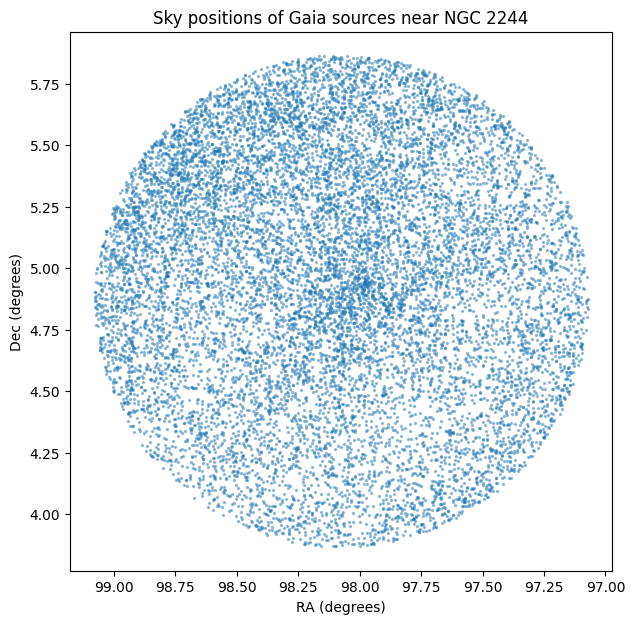

In [13]:
# Lets check out our data, and make sure we're not failures
# Plotting sky positions

plt.figure(figsize=(7, 7))
plt.scatter(df['ra'], df['dec'], s=2, alpha=0.4)
plt.xlabel('RA (degrees)')
plt.ylabel('Dec (degrees)')
plt.title('Sky positions of Gaia sources near NGC 2244')
plt.gca().invert_xaxis()  # RA increases to the left in sky maps
plt.show()

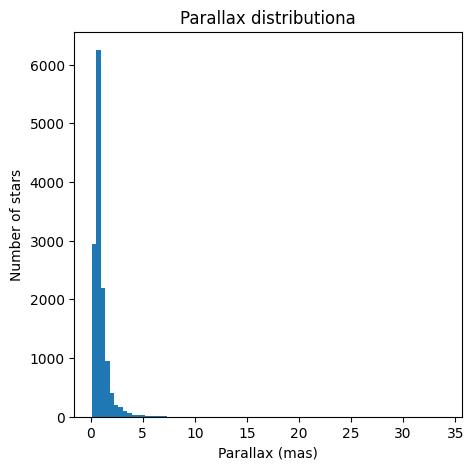

In [14]:
# Lets make a parallax histogram
# NGC 2244 is at ~1400 pc, which corresponds to a parallax of about 0.7 mas
# mas  = 1000 / distance

plt.figure(figsize=(5, 5))
plt.hist(df['parallax'], bins=80)
plt.xlabel('Parallax (mas)')
plt.ylabel('Number of stars')
plt.title('Parallax distributiona')
plt.show()

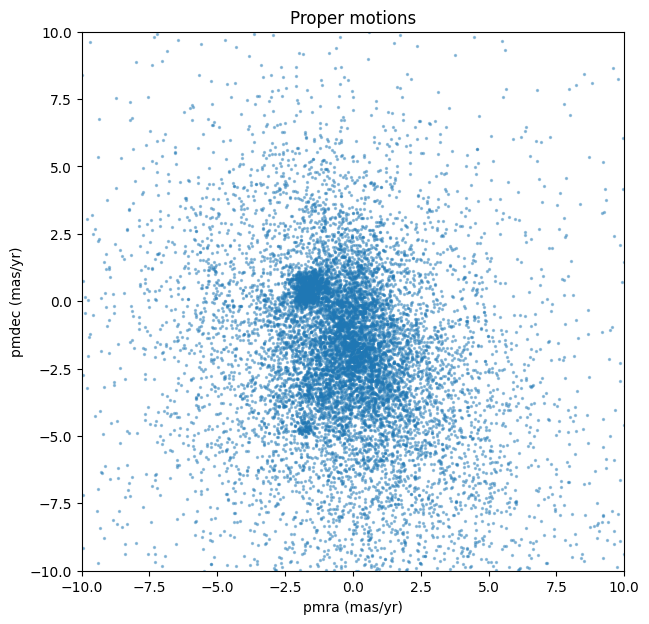

In [15]:
# Lets make a proper motion scatter plot
# Since we're looking at a cluster, we should expect tightly grouped PMs
# NGC 2244's proper motion is roughly (pmra, pmdec) = (-1.7, +0.3) mas/yr

plt.figure(figsize=(7, 7))
plt.scatter(df['pmra'], df['pmdec'], s=2, alpha=0.4)
plt.xlabel('pmra (mas/yr)')
plt.ylabel('pmdec (mas/yr)')
plt.title('Proper motions')
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.show()

In [16]:
# THE PLAN PART 2:
#    Pull the astrometric features the GMM will cluster on
#    We're using only astrometry for now, we can later train the
#    Random Forest on photometry
#    We will build a cleaned HR diagram using our groups of cluster and field stars
#
#    We will then run the GMM from sklearn

features = df[['parallax', 'pmra', 'pmdec']].values    # .values converts pandas df into a numpy array
print(f"Feature matrix shape: {features.shape}")       # this is awesome as it is what scikitlearn expects

Feature matrix shape: (13429, 3)


In [17]:
# STANDARDIZE THE FEATURES
#    So our features are 
#    parallax in mas with a range of about (0.5, 2),
#    pmra / pmdec in mas/yr with a range of about (-10, 10),
#        A GMM uses distances in feature space
#        so a feature with a bigger numerical range will dominate the clustering
#    So, lets put the features on the same scale before clustering (Standardizing)
#
#    In scikit-learn, we can use StandardScaler
#        It subtracts the mean and divides by the standard deviation, 
#        so every feature ends up with mean 0 and standard deviation 1

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
print(f"Mean of each scaled feature: {features_scaled.mean(axis=0)}")  # should be near 0
print(f"Standard Deviation of each scaled feature: {features_scaled.std(axis=0)}")    # should be 1

Mean of each scaled feature: [ 5.50275110e-17 -2.11644273e-18 -3.70377478e-17]
Standard Deviation of each scaled feature: [1. 1. 1.]


In [20]:
# RUN THE GAUSSIAN MIXTURE MODEL
#    We will use a GMM, a clustering algorithm that assumes the data is
#    a mixture of Gaussian distributions
#    We must tell it how many groups to look for
#    and it figures out where each one is centered, the range, and which data correlates to which group
#
#    We're using 2 components for our distributions
#        One for the tight clump of similar parallax and motion, cluster members
#        One for the loose cloud of random parallax and motion, field stars
#
#
#    After fitting using GaussianMixture, we get
#        labels, being a hard assignment (0 or 1) for each star's group
#        probs, probabilities for each star belonging to each group
#                  (probs[i] = [P(group 0), P(group 1)], and they sum to 1)
#
#    After we have our two groups, we will figure which is which by looking at the centroids

In [21]:
from sklearn.mixture import GaussianMixture

#    random_state=42 is a seed, GMM uses random starting points
#    so with a seed we can reproduce the same results

gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(features_scaled)

labels = gmm.predict(features_scaled)

probs = gmm.predict_proba(features_scaled)

print(f"Number of stars in group 0: {(labels == 0).sum()}")
print(f"Number of stars in group 1: {(labels == 1).sum()}")

Number of stars in group 0: 2008
Number of stars in group 1: 11421


In [22]:
#*** Many ML algorithms give you orobabilities of each classification, predict_proba
#        In most cases, we take the class with the largest proability as the classificaiton (predict)
#        Another option is to put a threshold on the classificaiton confidence

#    Then you must be careful for unbalanced classes

In [23]:
#***EXPLAIN THIS STEP
#*** Print the centroids of each component 

#*** Right now our proper motion looks so off, 
#*** I am Hoping this will improve with a larger sample size
#    Lowkey the field group will kinda always have a weird pm, as it is a more complex group 

centroids_scaled = gmm.means_
centroids = scaler.inverse_transform(centroids_scaled)

print("Component 0 centroid (parallax, pmra, pmdec):", centroids[0])
print("Component 1 centroid (parallax, pmra, pmdec):", centroids[1])

Component 0 centroid (parallax, pmra, pmdec): [ 2.25621215  1.22903642 -9.02042453]
Component 1 centroid (parallax, pmra, pmdec): [ 0.75602412 -0.26932556 -1.95907977]


In [24]:
# To choose which GMM component represents the cluster based on the centroids
# I will use the parallax of NGC 2244 which is about 0.7 mas, Component 0
# I will then use a boolean array, making True for cluster members and False for field stars


cluster_label =1  # *** or 1, depending on which centroid matched the cluster

is_member = (labels == cluster_label)
print(f"GMM identified {is_member.sum()} cluster member candidates")

GMM identified 11421 cluster member candidates


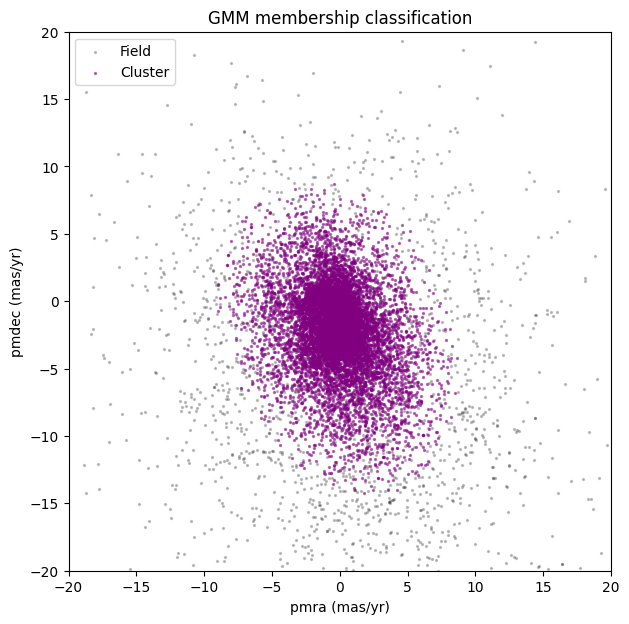

In [25]:
# Proper Motion PLot, 

plt.figure(figsize=(7, 7))
plt.scatter(df['pmra'][~is_member], df['pmdec'][~is_member], 
            s=2, alpha=0.2, label='Field', color='black')
plt.scatter(df['pmra'][is_member], df['pmdec'][is_member], 
            s=2, alpha=0.5, label='Cluster', color='purple')
plt.xlabel('pmra (mas/yr)')
plt.ylabel('pmdec (mas/yr)')
plt.title('GMM membership classification')
plt.xlim(-20, 20)
plt.ylim(-20, 20)
plt.legend()
plt.show()

In [26]:
# THE PLAN PART 3:
#    Build a cleaned HR diagram
#    If our Part 2 was correct, we should see the stars along the Main Sequence
#    
#    What our diagram needs
#        X axis should be color, we can use bp_rp, Bp-Rp,
#             the Blue Photometer's integrated magnitude which takes 330–680 nm
#             subtracted by the the Blue Photometer's integrated magnitude which takes 640–1050 nm
#
#        Y axis should be absolute magnitude, we can use phot_g_mean_mag, the apparent g magnitude
#             and apply the distance modulus formula to solve for the absolute magitude
#                 M = m -  5 * np.log10(d) + 5, which is also M = m + 5 * np.log10(parallax / 100)

In [27]:
#ABSOLUTE MAGNITUDE

df['abs_g'] = df['phot_g_mean_mag'] + 5 * np.log10(df['parallax'] / 100)

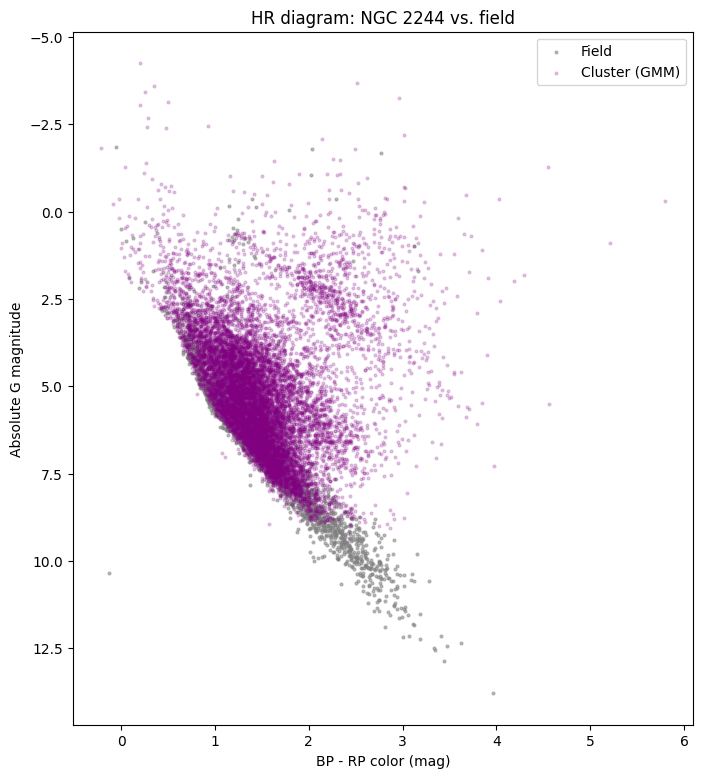

In [28]:
plt.figure(figsize=(8, 9))

# Field stars
plt.scatter(df['bp_rp'][~is_member], df['abs_g'][~is_member],
            s=4, alpha=0.5, color='gray', label='Field')

# Cluster members
plt.scatter(df['bp_rp'][is_member], df['abs_g'][is_member],
            s=4, alpha=0.2, color='purple', label='Cluster (GMM)')

plt.xlabel('BP - RP color (mag)')
plt.ylabel('Absolute G magnitude')
plt.title('HR diagram: NGC 2244 vs. field')
plt.gca().invert_yaxis()  # Bright stars at top
plt.legend()
plt.show()

In [29]:
member_parallaxes = df['parallax'][is_member]
mean_parallax = member_parallaxes.mean()
std_parallax = member_parallaxes.std()

# Convert parallax (mas) to distance (pc)
distance_pc = 1000 / mean_parallax
distance_pc_low = 1000 / (mean_parallax + std_parallax)
distance_pc_high = 1000 / (mean_parallax - std_parallax)

print(f"Mean parallax: {mean_parallax:.3f} ± {std_parallax:.3f} mas")
print(f"Estimated distance: {distance_pc:.0f} pc")
print(f"Distance range (±1σ): {distance_pc_low:.0f} to {distance_pc_high:.0f} pc")
print(f"Literature value: ~1400 pc")

Mean parallax: 0.756 ± 0.313 mas
Estimated distance: 1323 pc
Distance range (±1σ): 935 to 2259 pc
Literature value: ~1400 pc


In [30]:
# What Claude told us from our results
# Suggested fixes (try one or all)

#    More components. Try n_components=3, 4, or 5. 
#        The cluster is a tight Gaussian inside a much broader field distribution, 
#        so you need at least one component for the cluster, one for the field, 
#        and probably a few more for substructure in the field.

#    Use probabilities, not hard labels. 
#        Instead of labels == 1, threshold on 
#        probs[:, cluster_idx] > 0.9 or similar. 
#        This gives you high-confidence members and naturally removes 
#        borderline contamination.

#    Pre-filter before the GMM. 
#        A loose parallax cut like 0.5 < parallax < 1.0 mas would isolate 
#        the right distance range before clustering, dramatically improving 
#        the signal-to-noise.

#     Sanity check the centroid choice. 
#        Once you re-run, the cluster component should have ~few hundred 
#        to ~2000 stars, parallax near 0.7 mas, AND a small covariance 
#        (tight blob) — not just a centroid that happens to land in the right spot.

In [31]:
#When making RF, look fo rlabel noise
# and incorperating uncertainties into our machine learning

#Also see hwo cross-validation can be used to optimize hyperparameters (sec 8.11)

#Twofold, Leave one out, or K-fold or Leave P out
#Shuffle and split

In [32]:
#hello do you see me

In [33]:
#round 2


In [34]:
from sklearn import datasets
from pandas.plotting import scatter_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

In [ ]:
# IN CLASS EXAMPLE OF RANDOM FOREST


## We return to the iris dataset from last week. Load it into the notebook and make a pair plot:

#iris = datasets.load_iris()
#iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

#pd.plotting.scatter_matrix(iris_df, c = iris.target, figsize=(8, 8))
#plt.show()

## This time, let's classify it using a random forest. Initialize and train the random forest classifer 
## using cross validation. Repeat the above plot with the predicted classifications and calculate the overall accuracy

#ranforst = RandomForestClassifier()

#y = iris.target

#y_pred = cross_val_predict(ranforst, iris.data, y)

#iris_df['ranforst'] = y_pred


#pd.plotting.scatter_matrix(iris_df[iris.feature_names], c=iris_df['ranforst'], figsize=(6, 6))
#plt.suptitle("RandomForestClassifier")
#plt.show()

#accuracy_score(y_true, y_pred, *, normalize=True, sample_weight=None)
#acc_scr = accuracy_score(y, y_pred)
#print(' accuracy score:', acc_scr)

In [35]:
X_train, X_test, y_train, y_test

NameError: name 'X_train' is not defined